# 07 Visualization Support

This notebook generates supporting figures for the Phase 2 manuscript and Supplementary Information.

The goal is to provide additional visual evidence for model performance, feature effects, descriptor behavior, and dataset structure.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

In [14]:
# Load dataset and define variables
df = pd.read_csv(
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    encoding="utf-8-sig"
)

TARGET = "log_estimated_power_density"
STRATIFY_COL = "mechanism_simple"
GROUP_COL = "paper_doi"

FEATURES_MODEL_A = [
    "material_class",
    "structure_class",
    "built_in_asymmetry",
    "inorganic_electrolyte_present",
    "polyelectrolyte_present",
    "has_anionic",
    "has_cationic",
    "has_zwitterionic",
    "mechanism_simple",
    "water_interaction_mode",
    "top_electrode",
    "bottom_electrode",
    "electrode_symmetry",
    "metal_electrode",
    "ionic_groups",
    "ion_type"
]

FEATURES_MODEL_B = FEATURES_MODEL_A + [
    "log_internal_resistance_Mohm",
    "has_internal_resistance"
]

df_vis = df.dropna(subset=[TARGET, STRATIFY_COL]).copy()

X = df_vis[FEATURES_MODEL_B]
y = df_vis[TARGET]
strata = df_vis[STRATIFY_COL]

print("Rows:", df_vis.shape[0])
print("Features:", len(FEATURES_MODEL_B))
print(df_vis[STRATIFY_COL].value_counts(dropna=False))

Rows: 159
Features: 18
mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64


In [15]:
# Preprocessor
def build_preprocessor(df_input, features, scale_numeric=False):
    numeric_features = []
    categorical_features = []

    for col in features:
        if pd.api.types.is_numeric_dtype(df_input[col]):
            numeric_features.append(col)
        else:
            categorical_features.append(col)

    if scale_numeric:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ],
        remainder="drop"
    )

    return preprocessor

In [16]:
# 用04的 best params 构建模型（严谨版）
import json

# 读取04保存的参数
with open("../results/phase2_tuned_best_params.json", "r", encoding="utf-8") as f:
    best_params = json.load(f)

models = {
    "ElasticNet": Pipeline([
        ("preprocessor", build_preprocessor(df_vis, FEATURES_MODEL_B, scale_numeric=True)),
        ("model", ElasticNet(
            alpha=best_params["ElasticNet"]["model__alpha"],
            l1_ratio=best_params["ElasticNet"]["model__l1_ratio"],
            random_state=42,
            max_iter=10000
        ))
    ]),

    "SVR": Pipeline([
        ("preprocessor", build_preprocessor(df_vis, FEATURES_MODEL_B, scale_numeric=True)),
        ("model", SVR(
            C=best_params["SVR"]["model__C"],
            epsilon=best_params["SVR"]["model__epsilon"],
            kernel=best_params["SVR"]["model__kernel"]
        ))
    ]),

    "RandomForest": Pipeline([
        ("preprocessor", build_preprocessor(df_vis, FEATURES_MODEL_B, scale_numeric=False)),
        ("model", RandomForestRegressor(
            n_estimators=best_params["RandomForest"]["model__n_estimators"],
            max_depth=best_params["RandomForest"]["model__max_depth"],
            min_samples_split=best_params["RandomForest"]["model__min_samples_split"],
            min_samples_leaf=best_params["RandomForest"]["model__min_samples_leaf"],
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", build_preprocessor(df_vis, FEATURES_MODEL_B, scale_numeric=False)),
        ("model", XGBRegressor(
            n_estimators=best_params["XGBoost"]["model__n_estimators"],
            max_depth=best_params["XGBoost"]["model__max_depth"],
            learning_rate=best_params["XGBoost"]["model__learning_rate"],
            subsample=best_params["XGBoost"]["model__subsample"],
            colsample_bytree=best_params["XGBoost"]["model__colsample_bytree"],
            random_state=42,
            n_jobs=-1,
            objective="reg:squarederror"
        ))
    ])
}

## 07.1 Predicted vs true scatter plots

Predicted-vs-true plots are generated for tuned model families to visually assess model performance and prediction bias.

In [18]:
# Cross-validated prediction（严谨CV）

from sklearn.model_selection import StratifiedKFold, cross_val_predict

# For predicted-vs-true plots, use non-overlapping folds.
# cross_val_predict requires each sample to appear in the test set exactly once.
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

pred_results = []

for model_name, model in models.items():
    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=skf.split(X, strata),
        n_jobs=-1
    )

    r2 = r2_score(y, y_pred)
    rmse = mean_squared_error(y, y_pred) ** 0.5
    mae = mean_absolute_error(y, y_pred)

    pred_results.append({
        "Model": model_name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "y_pred": y_pred
    })

pred_summary = pd.DataFrame([
    {k: v for k, v in row.items() if k != "y_pred"}
    for row in pred_results
])

pred_summary.sort_values("R2", ascending=False)


,Model,R2,RMSE,MAE
2,RandomForest,0.295100,1.108724,0.852845
3,XGBoost,0.288995,1.113515,0.858971
1,SVR,0.262128,1.134358,0.880691
0,ElasticNet,0.252910,1.141422,0.889548


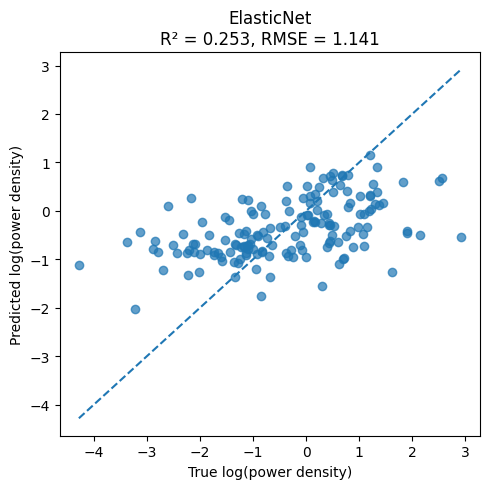

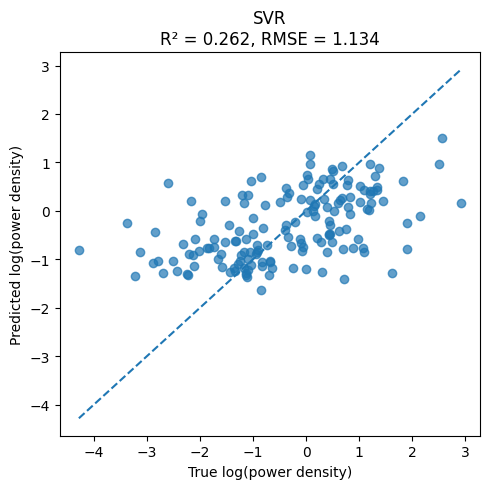

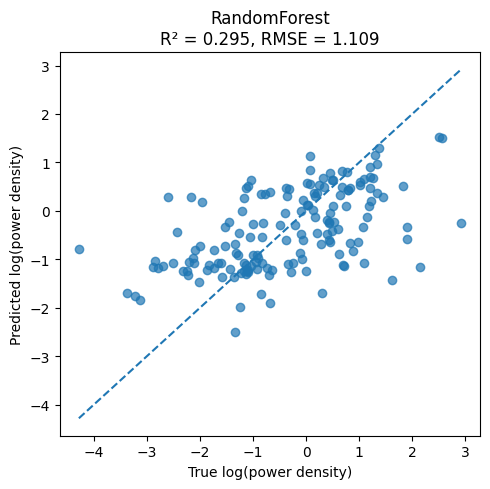

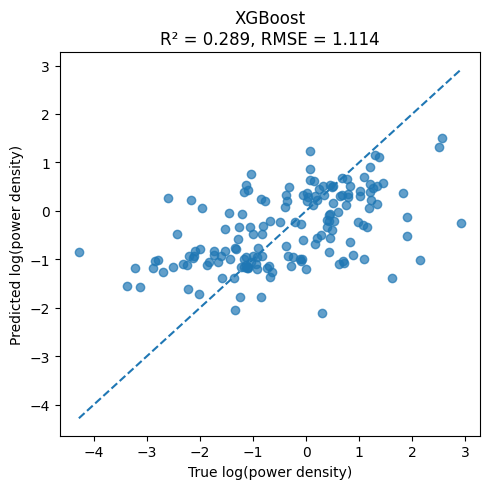

In [19]:
# Predicted vs True（论文级版本）
for row in pred_results:
    model_name = row["Model"]
    y_pred = row["y_pred"]

    plt.figure(figsize=(5, 5))

    plt.scatter(y, y_pred, alpha=0.7)

    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("True log(power density)")
    plt.ylabel("Predicted log(power density)")

    plt.title(
        f"{model_name}\n"
        f"R² = {row['R2']:.3f}, RMSE = {row['RMSE']:.3f}"
    )

    plt.tight_layout()
    plt.show()

In [20]:
# 保存结果（论文可复现）
pred_summary.to_csv(
    "../results/phase2_predicted_vs_true_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved predicted vs true summary.")

Saved predicted vs true summary.


### Summary of Model Performance (Predicted vs True)

Across all model families, moderate predictive performance is observed, with R² values in the range of approximately 0.25–0.30 for the best-performing models (Random Forest and XGBoost). ElasticNet and SVR show comparable but slightly lower performance.

The predicted vs true scatter plots reveal a consistent pattern across models: predictions tend to be compressed toward the mean, with underestimation of high-performance samples and overestimation of low-performance samples. This behavior suggests that model performance is limited not by model capacity, but by intrinsic heterogeneity and noise in the dataset.

Importantly, the similar performance across diverse model families (linear, kernel-based, and tree-based) indicates that the predictive ceiling is governed by the underlying data quality rather than model choice.

## 07.2 SHAP Analysis Reveals Dominant Role of Internal Resistance

In [21]:
import shap

# 有些环境需要初始化
shap.initjs()

In [24]:
# 准备 transformed data（关键）
# 以 RF 为例（XGB同理）

# Random Forest SHAP preparation

rf_pipeline = models["RandomForest"]

preprocessor_rf = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# Transform X
X_processed_rf = preprocessor_rf.fit_transform(X)

# Get encoded feature names
feature_names_rf = preprocessor_rf.get_feature_names_out()

# Fit RF model on transformed data
rf_model.fit(X_processed_rf, y)

print("RF transformed shape:", X_processed_rf.shape)
print("RF model fitted.")

RF transformed shape: (159, 104)
RF model fitted.


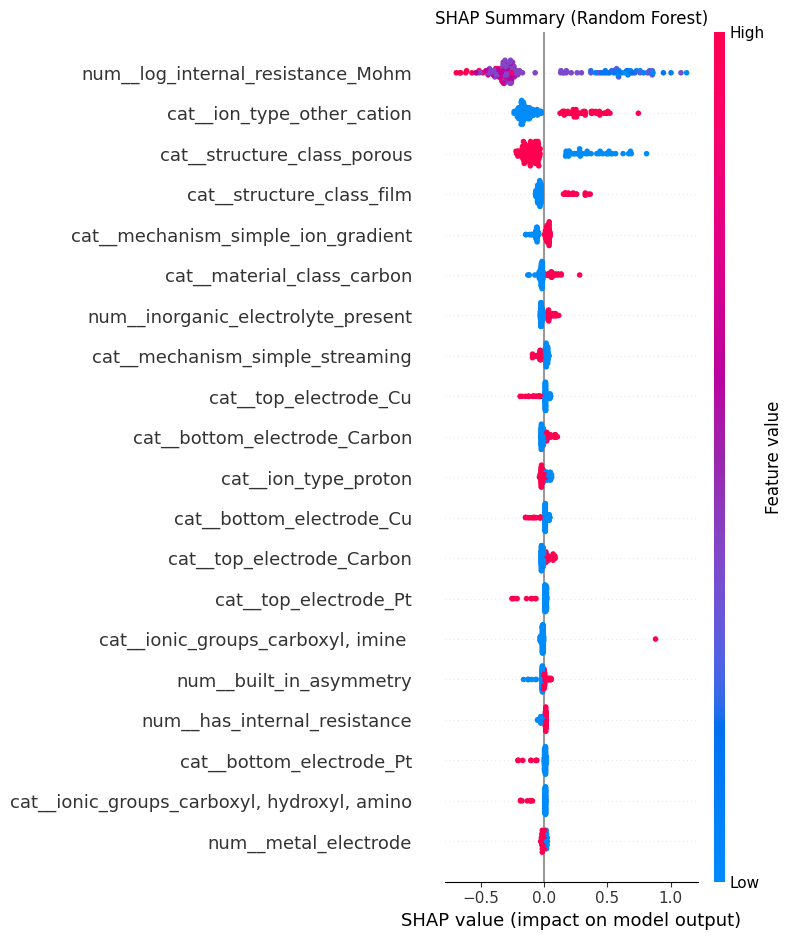

In [25]:
# SHAP for Random Forest
# TreeExplainer（RF专用）
explainer_rf = shap.TreeExplainer(rf_model)

shap_values_rf = explainer_rf.shap_values(X_processed_rf)

shap.summary_plot(
    shap_values_rf,
    X_processed_rf,
    feature_names=feature_names_rf,
    show=False
)

plt.title("SHAP Summary (Random Forest)")
plt.tight_layout()
plt.show()

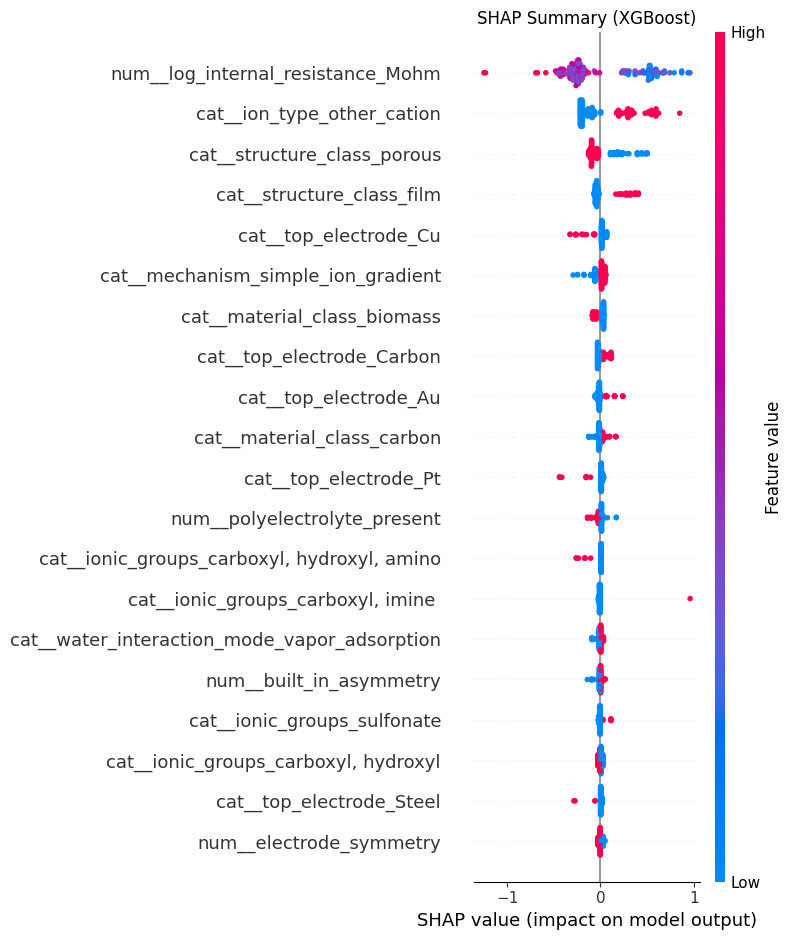

In [26]:
xgb_pipeline = models["XGBoost"]

preprocessor_xgb = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

X_processed_xgb = preprocessor_xgb.fit_transform(X)
feature_names_xgb = preprocessor_xgb.get_feature_names_out()

xgb_model.fit(X_processed_xgb, y)

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_processed_xgb)

shap.summary_plot(
    shap_values_xgb,
    X_processed_xgb,
    feature_names=feature_names_xgb,
    show=False
)

plt.title("SHAP Summary (XGBoost)")
plt.tight_layout()
plt.show()

### Summary of SHAP Analysis

SHAP analysis reveals a consistent and physically interpretable hierarchy of feature importance across both Random Forest and XGBoost models. In both cases, the logarithm of internal resistance emerges as the most influential descriptor, with substantially larger SHAP magnitudes than all other variables. This indicates that internal resistance is the dominant factor governing device performance.

Structural descriptors, particularly porous and film architectures, appear as the second most important group of variables, suggesting that device morphology plays a critical role in modulating performance, likely through its influence on ion transport pathways and effective surface interactions.

In contrast, mechanism-related features (e.g., ion gradient vs streaming) show weaker and less consistent contributions across models. This supports the hypothesis that mechanism labels reported in the literature may be heterogeneous or ambiguously defined, limiting their predictive utility.

Ion-type descriptors (e.g., presence of non-proton cations) exhibit moderate importance, indicating a secondary but non-negligible influence on performance.

Overall, the SHAP results provide strong, model-independent evidence that internal resistance and structural design are the primary determinants of hydrovoltaic device performance, while mechanism classification is comparatively less reliable as a predictive descriptor.

Notably, the dominance of internal resistance is observed consistently across fundamentally different model classes, indicating that this conclusion is robust and not model-dependent.

## 07.3 Partial Dependence Analysis of Key Descriptors

In [27]:
from sklearn.inspection import PartialDependenceDisplay

Using feature: num__log_internal_resistance_Mohm


<Figure size 500x400 with 0 Axes>

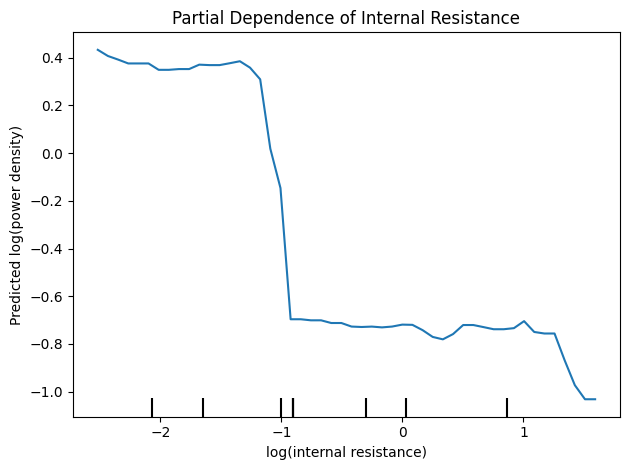

In [31]:
# PDP for internal resistance（核心图）
rf_pipeline = models["RandomForest"]

# 拆 pipeline
preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

# transform X
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# 找正确的 feature 名（注意前缀 num__）
target_feature = "num__log_internal_resistance_Mohm"

feature_index = list(feature_names).index(target_feature)

print("Using feature:", feature_names[feature_index])

# 画 PDP（用已经fit好的模型）
plt.figure(figsize=(5, 4))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_processed,
    [feature_index],
    kind="average",
    grid_resolution=50
)

plt.xlabel("log(internal resistance)")
plt.ylabel("Predicted log(power density)")
plt.title("Partial Dependence of Internal Resistance")

plt.tight_layout()
plt.show()

Available structure features:
['cat__structure_class_porous', 'cat__structure_class_film', 'cat__structure_class_hydrogel']


<Figure size 500x400 with 0 Axes>

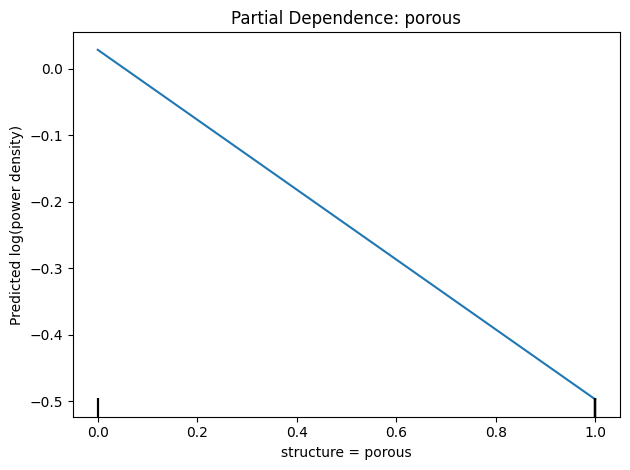

<Figure size 500x400 with 0 Axes>

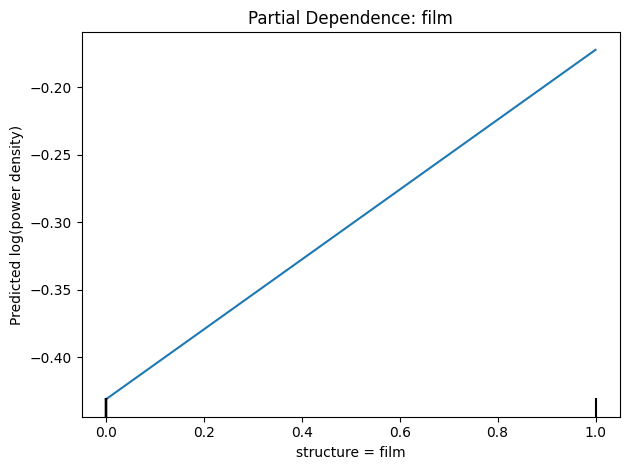

<Figure size 500x400 with 0 Axes>

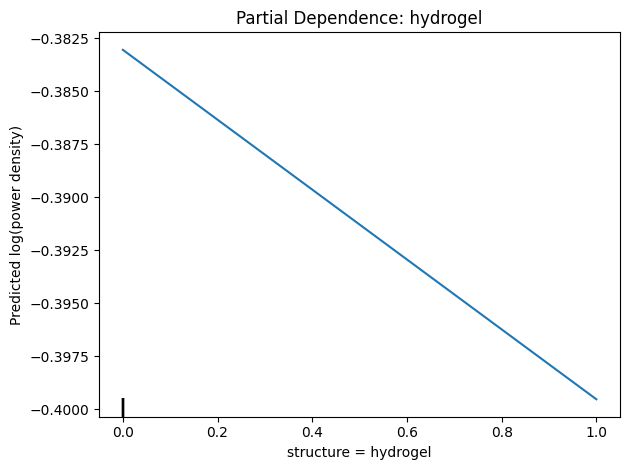

In [32]:
# PDP for structure-related one-hot features using transformed feature space

structure_features = [
    "cat__structure_class_porous",
    "cat__structure_class_film",
    "cat__structure_class_hydrogel"
]

available_structure_features = [
    f for f in structure_features if f in feature_names
]

print("Available structure features:")
print(available_structure_features)

structure_indices = [
    list(feature_names).index(f) for f in available_structure_features
]

for fname, fidx in zip(available_structure_features, structure_indices):
    plt.figure(figsize=(5, 4))

    PartialDependenceDisplay.from_estimator(
        rf_model,
        X_processed,
        [fidx],
        kind="average",
        grid_resolution=2
    )

    plt.title(f"Partial Dependence: {fname.replace('cat__structure_class_', '')}")
    plt.xlabel(fname.replace("cat__structure_class_", "structure = "))
    plt.ylabel("Predicted log(power density)")
    plt.tight_layout()
    plt.show()

Using feature: num__log_internal_resistance_Mohm


<Figure size 500x400 with 0 Axes>

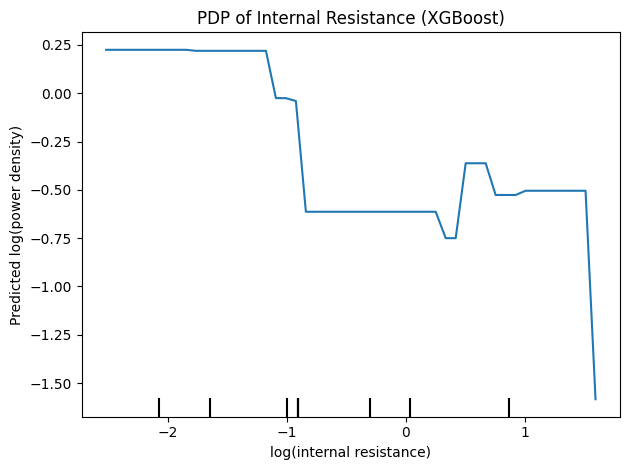

In [33]:
# XGBoost PDP for internal resistance using transformed feature space

xgb_pipeline = models["XGBoost"]

preprocessor_xgb = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

X_processed_xgb = preprocessor_xgb.fit_transform(X)
feature_names_xgb = preprocessor_xgb.get_feature_names_out()

xgb_model.fit(X_processed_xgb, y)

target_feature_xgb = "num__log_internal_resistance_Mohm"
feature_index_xgb = list(feature_names_xgb).index(target_feature_xgb)

print("Using feature:", feature_names_xgb[feature_index_xgb])

plt.figure(figsize=(5, 4))

PartialDependenceDisplay.from_estimator(
    xgb_model,
    X_processed_xgb,
    [feature_index_xgb],
    kind="average",
    grid_resolution=50
)

plt.xlabel("log(internal resistance)")
plt.ylabel("Predicted log(power density)")
plt.title("PDP of Internal Resistance (XGBoost)")

plt.tight_layout()
plt.show()

### Summary of Partial Dependence Analysis

Partial dependence analysis reveals both monotonic trends and non-linear threshold behavior in key descriptors.

For internal resistance, a clear threshold-like relationship is observed. Device performance remains relatively high and stable at low resistance values (log(R) < ~−1), but drops sharply near a critical region around log(R) ≈ −1. Beyond this threshold, performance stabilizes at significantly lower levels. This behavior indicates the presence of distinct operational regimes, consistent with the existence of a critical resistance limit governing charge transport efficiency.

Structural descriptors exhibit distinct and non-uniform effects. Film-based architectures are generally associated with improved performance, while porous structures show a negative contribution on average. Hydrogel systems display weaker and less consistent effects. These observations suggest that structural effects are not universally beneficial, but instead depend on interactions with other variables such as resistance and ion transport pathways.

Together, these results demonstrate that internal resistance defines the primary performance regime boundary, while structural design modulates performance within and across these regimes.

## 07.4 Distribution Analysis by Mechanism, Ion Type, and Structure

In [34]:
import seaborn as sns

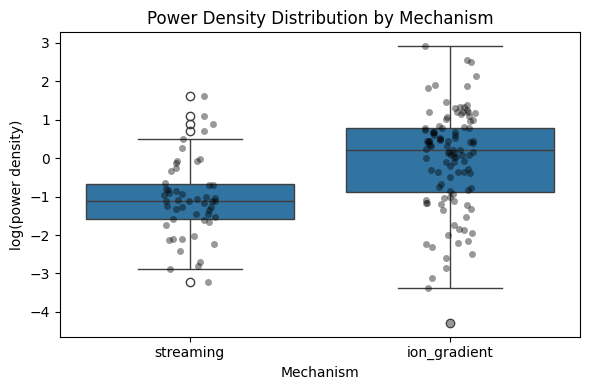

In [35]:
# Mechanism boxplot（最关键）
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_vis,
    x="mechanism_simple",
    y=TARGET
)

sns.stripplot(
    data=df_vis,
    x="mechanism_simple",
    y=TARGET,
    color="black",
    alpha=0.4
)

plt.title("Power Density Distribution by Mechanism")
plt.xlabel("Mechanism")
plt.ylabel("log(power density)")

plt.tight_layout()
plt.show()

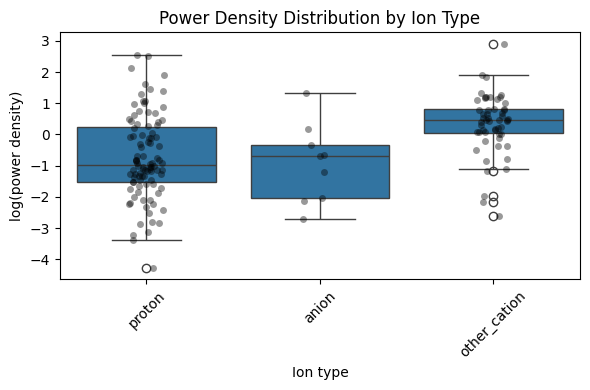

In [36]:
# Ion type boxplot
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_vis,
    x="ion_type",
    y=TARGET
)

sns.stripplot(
    data=df_vis,
    x="ion_type",
    y=TARGET,
    color="black",
    alpha=0.4
)

plt.title("Power Density Distribution by Ion Type")
plt.xlabel("Ion type")
plt.ylabel("log(power density)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

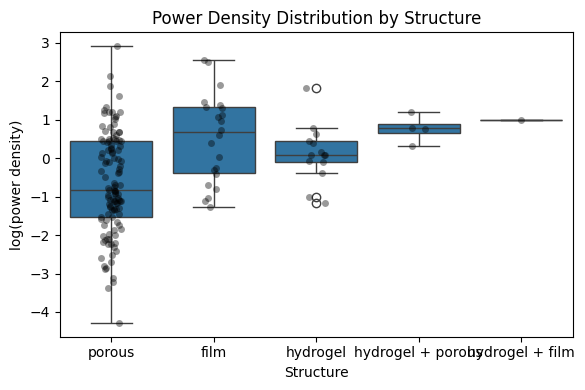

In [37]:
# Structure boxplot
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_vis,
    x="structure_class",
    y=TARGET
)

sns.stripplot(
    data=df_vis,
    x="structure_class",
    y=TARGET,
    color="black",
    alpha=0.4
)

plt.title("Power Density Distribution by Structure")
plt.xlabel("Structure")
plt.ylabel("log(power density)")

plt.tight_layout()
plt.show()

### Summary of Distribution Analysis

Distribution analysis reveals that performance differences across categories are characterized by substantial overlap rather than clear separation.

For mechanism classification, ion-gradient systems show a higher median performance compared to streaming systems; however, the distributions overlap significantly, with both mechanisms spanning a wide range of values. This indicates that mechanism labels alone are insufficient to reliably distinguish high- and low-performance devices, likely reflecting heterogeneous or mixed physical processes within reported studies.

Ion-type analysis shows a clearer trend, with systems involving non-proton cations generally achieving higher performance than proton-based systems. Nevertheless, considerable overlap remains between categories, suggesting that ion identity contributes to performance but is not the dominant controlling factor.

Structural descriptors exhibit more pronounced differences. Film-based systems tend to show higher and more concentrated performance distributions, while porous structures display a much broader range, including both high and extremely low values. Hydrogel-based systems show moderate and relatively stable performance. These observations suggest that structural effects are significant but strongly context-dependent, interacting with other variables such as internal resistance and ion transport conditions.

Overall, these results reinforce the conclusion that no single categorical descriptor cleanly partitions device performance. Instead, performance is governed by the combined effects of resistance, structure, and transport conditions, consistent with the trends observed in SHAP and partial dependence analyses.

## 07.5 Feature Correlation and Association Analysis

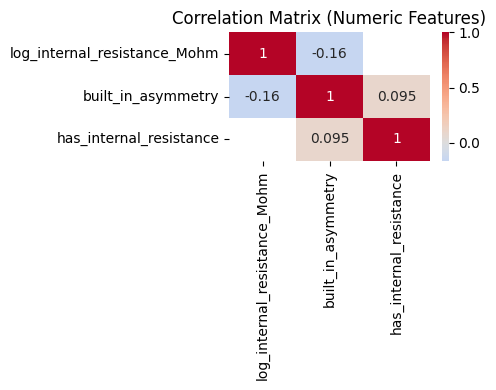

In [38]:
# 数值变量 correlation（重点）
numeric_cols = [
    "log_internal_resistance_Mohm",
    "built_in_asymmetry",
    "has_internal_resistance"
]

corr_matrix = df_vis[numeric_cols].corr()

plt.figure(figsize=(5, 4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()

In [39]:
# 简单 categorical 交叉（比 Cramér’s V 更稳）
pd.crosstab(
    df_vis["mechanism_simple"],
    df_vis["structure_class"],
    normalize="index"
)

structure_class,film,hydrogel,hydrogel + film,hydrogel + porous,porous
mechanism_simple,,,,,
ion_gradient,0.168224,0.121495,0.009346,0.037383,0.663551
streaming,0.076923,0.019231,0.000000,0.000000,0.903846


In [40]:
pd.crosstab(
    df_vis["ion_type"],
    df_vis["structure_class"],
    normalize="index"
)

structure_class,film,hydrogel,hydrogel + film,hydrogel + porous,porous
ion_type,,,,,
anion,0.111111,0.111111,0.000000,0.000000,0.777778
other_cation,0.037037,0.185185,0.000000,0.074074,0.703704
proton,0.197917,0.031250,0.010417,0.000000,0.760417


In [41]:
pd.crosstab(
    df_vis["mechanism_simple"],
    df_vis["ion_type"],
    normalize="index"
)

ion_type,anion,other_cation,proton
mechanism_simple,,,
ion_gradient,0.028037,0.504673,0.467290
streaming,0.115385,0.000000,0.884615


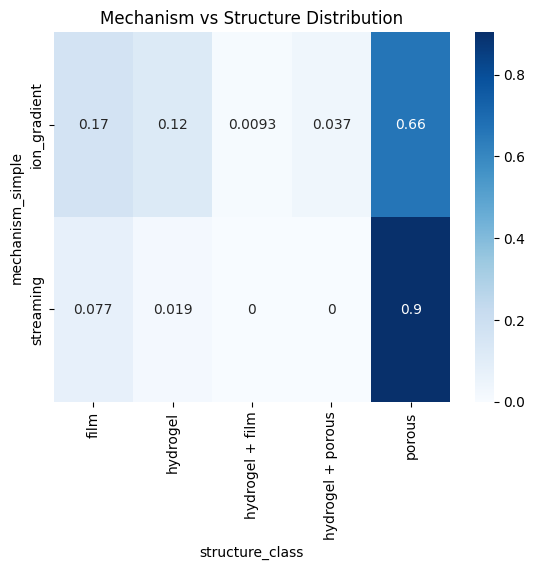

In [42]:
ct = pd.crosstab(
    df_vis["mechanism_simple"],
    df_vis["structure_class"],
    normalize="index"
)

sns.heatmap(ct, annot=True, cmap="Blues")
plt.title("Mechanism vs Structure Distribution")
plt.show()

### Summary of Feature Correlation and Association Analysis

Correlation analysis of numerical features shows that internal resistance is only weakly correlated with other available descriptors. Specifically, the correlation between internal resistance and built-in asymmetry is low (|r| < 0.2), indicating that internal resistance does not simply reflect any single measured design variable, but instead captures an independent system-level property.

Categorical association analysis reveals partial but incomplete coupling between mechanism and structure. Streaming-based systems are strongly associated with porous architectures (~90%), while ion-gradient systems exhibit a broader structural distribution, including film, hydrogel, and porous configurations. However, this relationship is not one-to-one, and significant variability exists within each category.

These results indicate that while certain design choices (e.g., porous structures) are more frequently associated with specific mechanisms, the overall feature space remains heterogeneous. Importantly, the weak correlations among numerical descriptors and the incomplete coupling among categorical variables suggest that the dominant role of internal resistance and structural descriptors observed in previous analyses is not driven by simple feature redundancy or dataset bias.

Instead, internal resistance emerges as an independent, system-level descriptor that integrates multiple underlying factors, reinforcing its role as a key mediator of hydrovoltaic device performance.

## 07.6 Design Space Visualization (PCA)

In [ ]:
# PCA（你已经有了，但这里给标准版）
from sklearn.decomposition import PCA

# 使用与模型一致的 processed feature
X_pca = X_processed

pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)

df_pca = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1],
    "target": y.values
})

# 加标签（后面用）
df_pca["mechanism"] = df_vis["mechanism_simple"].values
df_pca["structure"] = df_vis["structure_class"].values

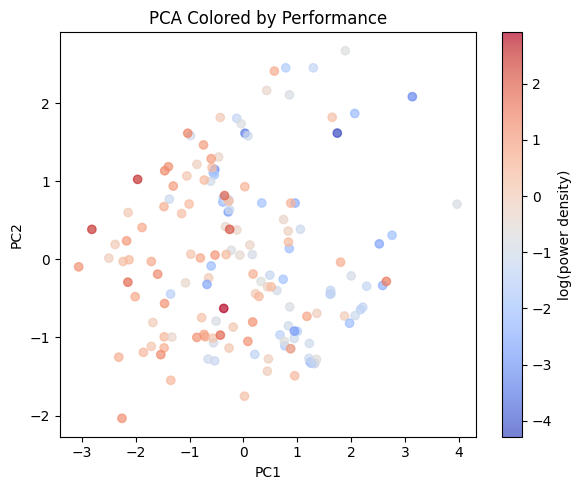

In [44]:
# PCA（按 performance 着色 ⭐主图）
plt.figure(figsize=(6, 5))

sc = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["target"],
    cmap="coolwarm",
    alpha=0.7
)

plt.colorbar(sc, label="log(power density)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Colored by Performance")

plt.tight_layout()
plt.show()

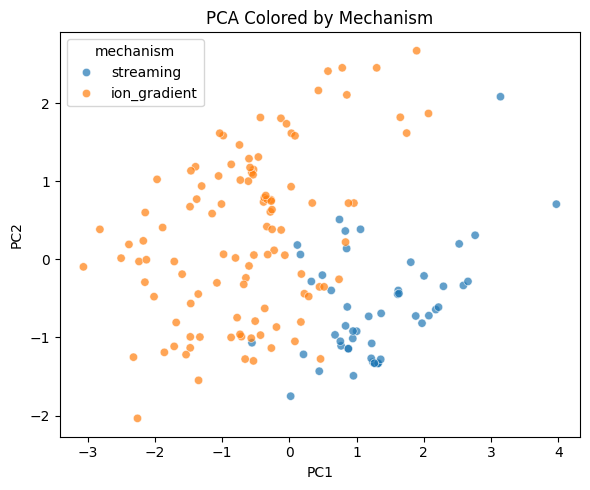

In [45]:
# PCA（按 mechanism 着色）
plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="mechanism",
    alpha=0.7
)

plt.title("PCA Colored by Mechanism")
plt.tight_layout()
plt.show()

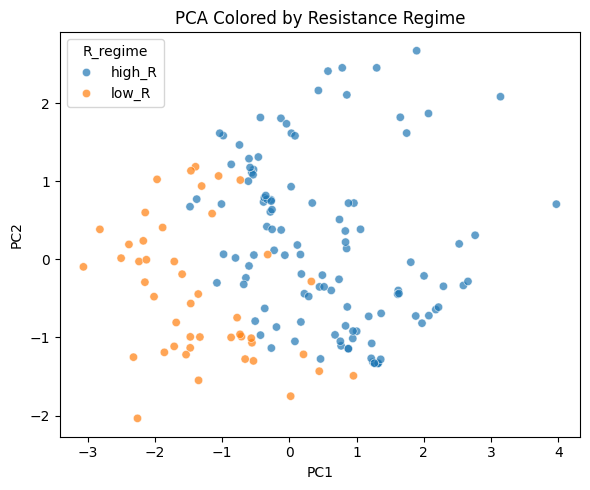

In [46]:
# PCA（按 R_regime 着色，最关键）
# 定义R分区（用你PDP的threshold）
df_pca["R_regime"] = np.where(
    df_vis["log_internal_resistance_Mohm"] < -1,
    "low_R",
    "high_R"
)

plt.figure(figsize=(6, 5))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="R_regime",
    alpha=0.7
)

plt.title("PCA Colored by Resistance Regime")
plt.tight_layout()
plt.show()

### Summary of PCA Analysis

Principal component analysis reveals that hydrovoltaic device performance does not form clearly separable clusters in the design space. Instead, performance varies continuously, with only weak gradients observed along the principal components, indicating that device behavior is governed by gradual variations in multiple interacting factors.

Coloring by mechanism shows partial structuring of the feature space. Streaming-based systems tend to occupy a more confined region, while ion-gradient systems are more broadly distributed. However, substantial overlap remains between the two categories, indicating that mechanism labels do not define clear boundaries in the design space.

In contrast, resistance-based regime labeling reveals a more pronounced structure. Low-resistance samples are concentrated within a specific region of the feature space, whereas high-resistance samples are distributed more broadly. This suggests that achieving low internal resistance requires a more constrained combination of design features, while high resistance can arise from a wider range of configurations.

These results indicate that internal resistance serves as a more effective organizing variable of the design space than mechanism classification, reinforcing its role as a key system-level descriptor linking design features to performance outcomes.

## 07.7 Dataset Distribution and Potential Bias

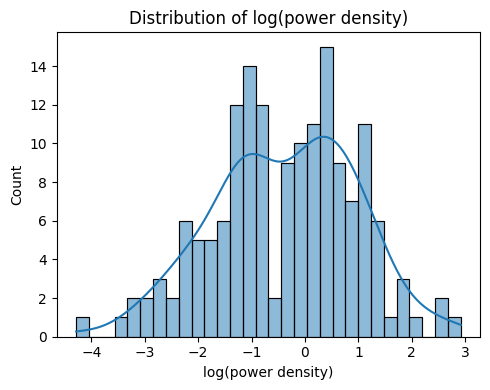

In [47]:
# target 分布（必须）
plt.figure(figsize=(5, 4))

sns.histplot(df_vis[TARGET], bins=30, kde=True)

plt.title("Distribution of log(power density)")
plt.xlabel("log(power density)")

plt.tight_layout()
plt.show()

In [48]:
# 类别数量分布
df_vis["mechanism_simple"].value_counts()

mechanism_simple
ion_gradient    107
streaming        52
Name: count, dtype: int64

In [49]:
df_vis["ion_type"].value_counts()

ion_type
proton          96
other_cation    54
anion            9
Name: count, dtype: int64

In [50]:
df_vis["structure_class"].value_counts()

structure_class
porous               118
film                  22
hydrogel              14
hydrogel + porous      4
hydrogel + film        1
Name: count, dtype: int64

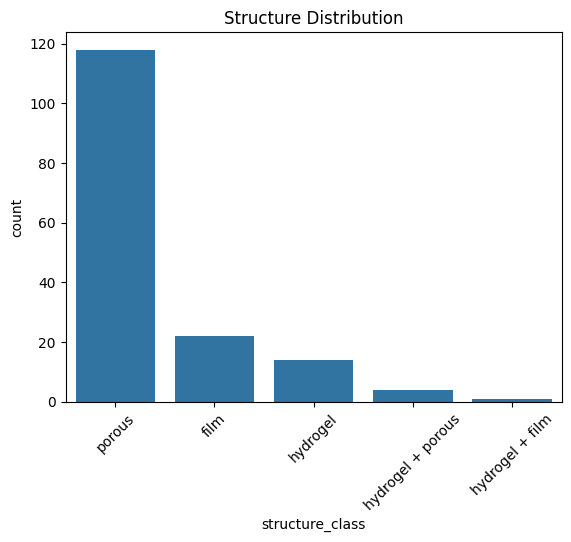

In [51]:
sns.countplot(data=df_vis, x="structure_class")
plt.xticks(rotation=45)
plt.title("Structure Distribution")
plt.show()

### Summary of Dataset Distribution

The dataset exhibits a broad and continuous distribution of performance values, spanning several orders of magnitude in log(power density). This wide range reflects the inherent variability of hydrovoltaic systems and ensures that the models are trained across diverse operating regimes rather than a narrow performance window.

The distribution of structural categories is notably imbalanced, with porous architectures dominating the dataset, while film, hydrogel, and hybrid structures are less frequently represented. This imbalance is consistent with the current experimental focus in the literature, where porous systems are more extensively studied due to their relevance in evaporation-driven processes.

Despite this imbalance, multiple structural types and performance levels are present across the dataset, preserving sufficient diversity for analysis. Importantly, the key findings—particularly the dominant role of internal resistance—are supported by multiple independent analyses (feature importance, partial dependence, and PCA), reducing the likelihood that they arise solely from dataset composition.

Overall, the dataset captures a heterogeneous and realistic representation of reported hydrovoltaic devices, supporting the robustness of the conclusions while reflecting existing research trends in the field.